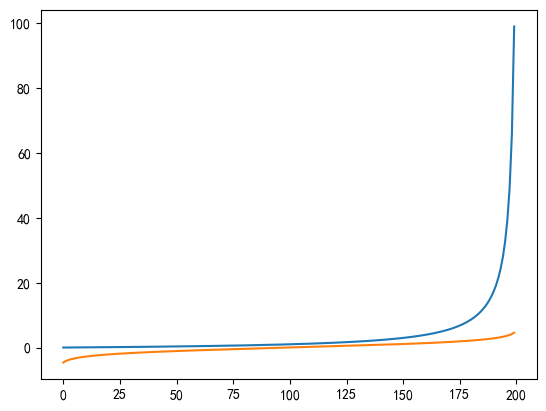

In [1]:
import numpy as np
import matplotlib.pyplot as plt
p1=np.linspace(0.01,0.99,200)
p0=1-p1
plt.plot(p1/p0)
plt.plot(np.log(p1/p0))


Text(0, 0.5, 'sigmoid(z)')

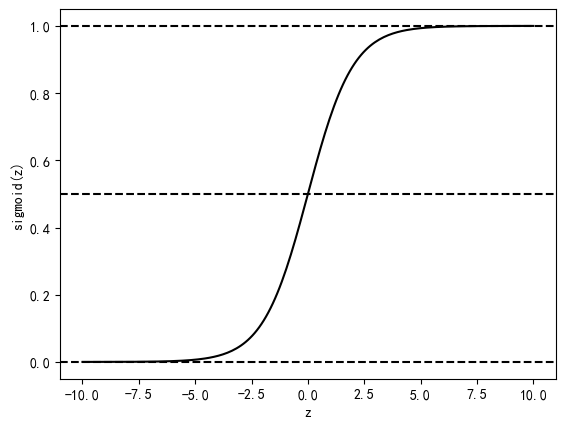

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z), c='k')
plt.axhline(ls="--", c='k')
plt.axhline(y=0.5, ls="--", c='k')
plt.axhline(y=1, ls="--", c='k')
plt.xlabel("z")
plt.ylabel("sigmoid(z)")

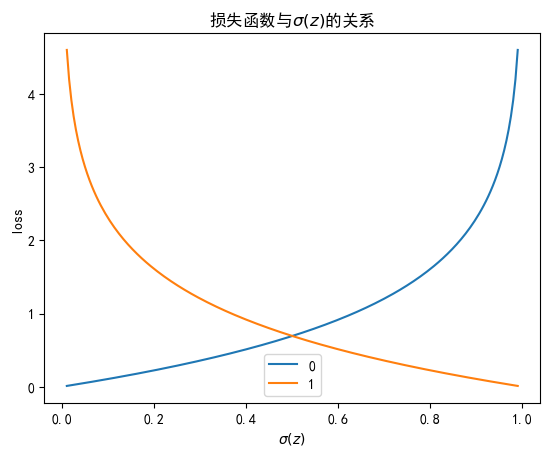

In [3]:
s=np.linspace(0.01,0.99,200)
for y in [0,1]:
    #计算对数损失函数的值
    loss=-y*np.log(s)-(1-y)*np.log(1-s)
    plt.plot(s,loss,label=f'{y}')
    plt.legend()
    plt.xlabel('$\sigma(z)$')
    plt.ylabel('loss')
    plt.title('损失函数与$\sigma(z)$的关系')

In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X, y = iris.data, iris.target
print(X.shape, y.shape)
print(X[:5])
print(y[:5])
print(iris.feature_names)
print(iris.target_names)
# print(iris.DESCR)
print(np.unique(y))
print(pd.Series(y).value_counts())
# 返回从0开始，到数组中最大值为止，每个整数值出现的次数。
print(np.bincount(y))
print(np.bincount([0, 0, 5, 5, 5]))

(150, 4) (150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
[0 1 2]
0    50
1    50
2    50
Name: count, dtype: int64
[50 50 50]
[2 0 0 0 0 3]


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# return_X_y：是否仅返回X与y，默认为False。
X, y = load_iris(return_X_y=True)
# 我们这里取两个特征，两个类别。
X = X[y != 0, 2:]
y = y[y != 0]
# 习惯上，二分类的标签设置为0与1（非必须）。
y[y == 1] = 0
y[y == 2] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("权重：", lr.coef_)
print("偏置：", lr.intercept_)
y_pred = lr.predict(X_test)
print("真实值：", y_test)
print("预测值：", y_pred)

权重： [[2.54334475 2.15611339]]
偏置： [-16.08373212]
真实值： [1 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]
预测值： [1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]


[[0.46966326 0.53033674]
 [0.98283042 0.01716958]
 [0.72577438 0.27422562]
 [0.91248826 0.08751174]
 [0.80289869 0.19710131]]
[1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]
[1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1]


Text(0.5, 1.0, '逻辑回归分类概率')

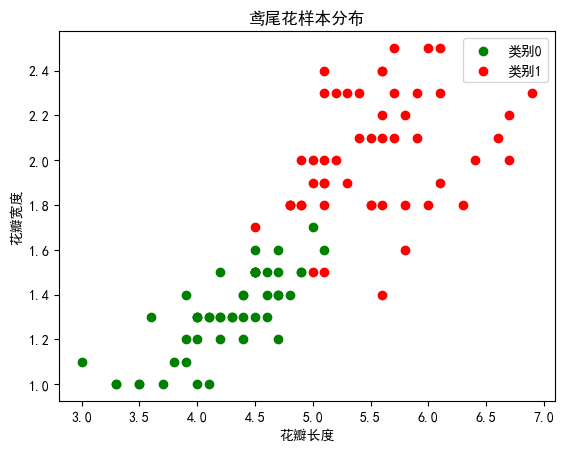

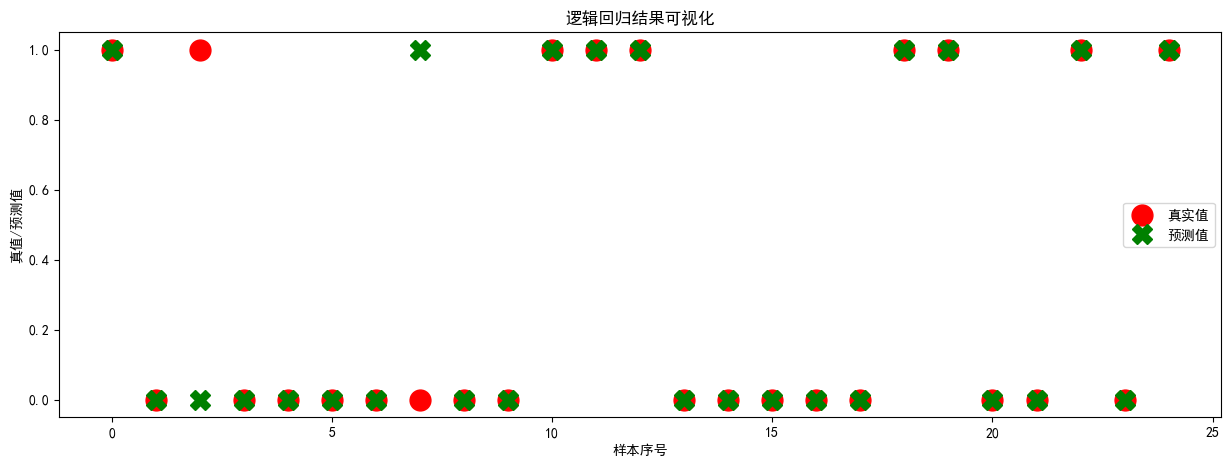

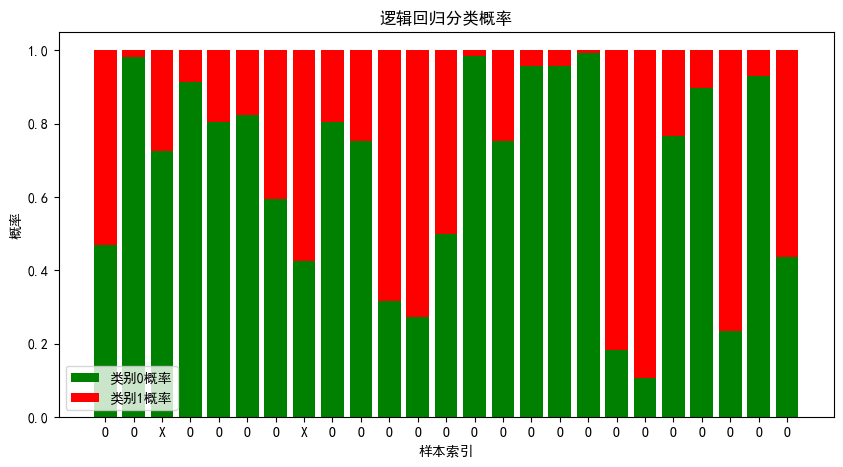

In [6]:
c1 = X[y == 0]
c2 = X[y == 1]
plt.scatter(c1[:, 0], c1[:, 1], c="g", label="类别0")
plt.scatter(c2[:, 0], c2[:, 1], c="r", label="类别1")
plt.xlabel("花瓣长度")
plt.ylabel("花瓣宽度")
plt.title("鸢尾花样本分布")
plt.legend()

plt.figure(figsize=(15, 5))
plt.plot(y_test, marker="o", ls="", ms=15, c="r", label="真实值")
plt.plot(y_pred, marker="X", ls="", ms=15, c="g", label="预测值")
plt.legend()
plt.xlabel("样本序号")
plt.ylabel("真值/预测值")
plt.title("逻辑回归结果可视化")


proba = lr.predict_proba(X_test)
print(proba[:5])
print(np.argmax(proba, axis=1))
print(lr.predict(X_test))

index = np.arange(X_test.shape[0])
proba_0 = proba[:, 0]
proba_1 = proba[:, 1]
tick_label = np.where(y_test == y_pred, "O", "X")
plt.figure(figsize=(10, 5))
plt.bar(index, height=proba_0, color="g", label="类别0概率")
plt.bar(index, height=proba_1, color="r", bottom=proba_0, label="类别1概率", tick_label=tick_label)
plt.legend()
plt.xlabel("样本索引")
plt.ylabel("概率")
plt.title("逻辑回归分类概率")

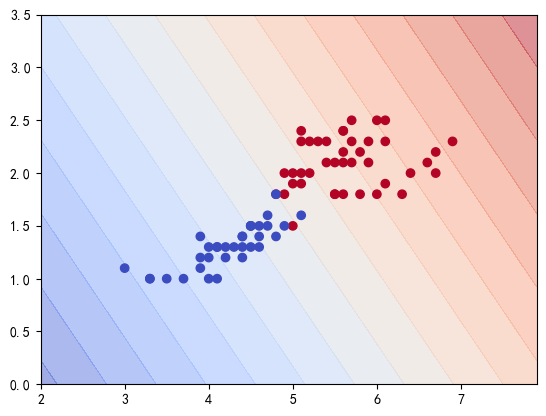

In [7]:
from sklearn.inspection import DecisionBoundaryDisplay
#根据模型绘制决策边界
#estimator:需要绘制决策边界的模型
#X:二维数组,必须具有两个特征,用于确定决策边界每个维度的范围(最小值和最大值)
#response_method:使用模型的哪个方法作为结果绘制决策边界
#grid_resolution:网格分辨率
# plot_method:绘制等高线的方式
#颜色也可以指定数值,此时必须要提供cmap,因为数值的颜色是从cmap里选择颜色

DecisionBoundaryDisplay.from_estimator(lr,X_train,response_method='decision_function',grid_resolution=200,cmap=plt.cm.coolwarm,alpha=0.5,levels=20)
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap=plt.cm.coolwarm)

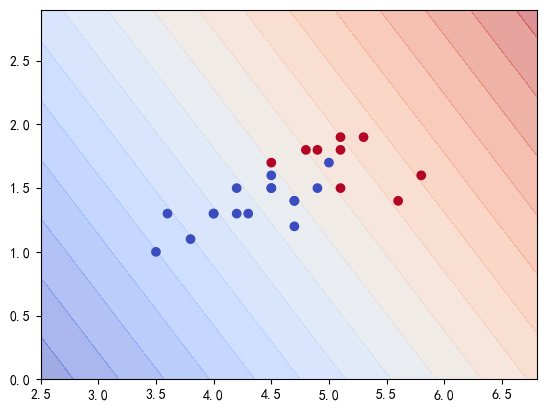

In [8]:
DecisionBoundaryDisplay.from_estimator(lr,X_test,response_method='decision_function',grid_resolution=200,cmap=plt.cm.coolwarm,alpha=0.5,levels=20)
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap=plt.cm.coolwarm)

[[-1.05235359 -1.54997278]
 [ 0.5112642  -0.99971085]
 [ 0.06587216  2.2622871 ]]
[ 3.55461523 -1.49736269 -3.80220312]
[[-2.52712826 -1.05739753]
 [ 0.06520905 -0.68620497]
 [ 2.46191922  1.7436025 ]]
[ 10.06780374   2.76229247 -12.83009621]


c:\ai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


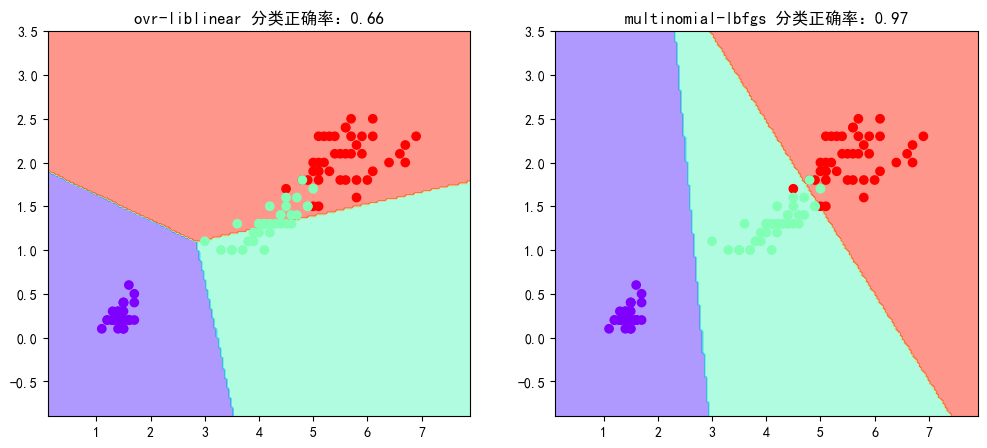

In [9]:
X, y = load_iris(return_X_y=True)
X = X[:, 2:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
params = [("ovr", "liblinear"), ("multinomial", "lbfgs")]
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for index, (mc, s) in enumerate(params):
    lr = LogisticRegression(multi_class=mc, solver=s)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    # 计算正确率。
    accuracy = np.mean(y_test == y_pred)
    ax[index].set_title(f"{mc}-{s} 分类正确率：{accuracy:.2f}")
    # 绘制决策边界。
    DecisionBoundaryDisplay.from_estimator(lr, X_train, response_method="predict", grid_resolution=200,
                        cmap=plt.cm.rainbow, alpha=0.5, ax=ax[index])
    ax[index].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.rainbow)
    print(lr.coef_)
    print(lr.intercept_)

In [15]:
lr=LogisticRegression(multi_class='ovr',solver='liblinear')
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)
print(lr.predict_proba(X_test[:1]))
z0=X_test[0]@lr.coef_[0]+lr.intercept_[0]
z1=X_test[0]@lr.coef_[1]+lr.intercept_[1]
z2=X_test[0]@lr.coef_[2]+lr.intercept_[2]
z=np.array([z0,z1,z2])
p=1/(1+np.exp(-z))
p=p/p.sum()
print(p)

[[-1.05235359 -1.54997278]
 [ 0.5112642  -0.99971085]
 [ 0.06587216  2.2622871 ]]
[ 3.55461523 -1.49736269 -3.80220312]
[[0.00359333 0.19692104 0.79948563]]
[0.00359333 0.19692104 0.79948563]


c:\ai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [16]:
lr=LogisticRegression(multi_class='multinomial',solver='lbfgs')
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)
print(lr.predict_proba(X_test[:1]))
z0=X_test[0]@lr.coef_[0]+lr.intercept_[0]
z1=X_test[0]@lr.coef_[1]+lr.intercept_[1]
z2=X_test[0]@lr.coef_[2]+lr.intercept_[2]
z=np.array([z0,z1,z2])
ez=np.exp(z)
print(ez/ez.sum())

[[-2.52712826 -1.05739753]
 [ 0.06520905 -0.68620497]
 [ 2.46191922  1.7436025 ]]
[ 10.06780374   2.76229247 -12.83009621]
[[8.69198992e-05 7.85317407e-02 9.21381339e-01]]
[8.69198992e-05 7.85317407e-02 9.21381339e-01]


c:\ai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
